# Esewa Data Analyst Assessment (Round 2)
**What I did:** I worked on three of the assignment tasks - exploring the data (Task 1), grouping customers into segments (Task 2), and building a dashboard in Power BI (Task 4). I also added a simple trend projection to cover the forward-looking question, instead of building a full forecasting model (Task 3).

**About the data:** No dataset was given for this assessment, so I created a realistic synthetic one instead - about 1 million users and 25 million transactions, styled after a Nepali digital-wallet business. **This is made-up data, not real numbers from any actual company.** I deliberately built in realistic patterns (busy periods, an outage, drop-offs during identity verification, suspicious-looking transactions) as well as realistic messiness (duplicate rows, missing values) so the analysis would have real problems to solve. I also kept a hidden "answer key" for what each customer's true segment should be, and only used it at the very end to check my grouping - the analysis itself never saw it, which keeps the results honest.

**How to run this notebook:** near the top there's a `SCALE` setting - choose `"dev"` for a quick test with 20,000 users (~2 minutes) or `"full"` for all 1 million users (~10–15 minutes, needs a decent amount of memory and disk space). Then run all the cells top to bottom. If the data has already been generated once, it won't regenerate - delete the `esewa_data/` folder if you want to start fresh.


In [1]:
import os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})

SCALE   = os.environ.get("SCALE", "full") #dev or full
N_TOTAL = 1_000_000 if SCALE == "full" else 20_000
BATCH   =   100_000 if SCALE == "full" else 20_000
START, END = pd.Timestamp("2024-08-01"), pd.Timestamp("2026-08-01")
DAYS = (END - START).days

ROOT = Path("esewa_data")
RAW, CLEAN, AGG = ROOT/"raw", ROOT/"clean", ROOT/"agg"
PBI, FIG = Path("pbi_exports"), Path("report_assets")
for p in (RAW, CLEAN, AGG, PBI, FIG): p.mkdir(parents=True, exist_ok=True)

def save_show(fig, name, title):
    fig.suptitle(title); fig.tight_layout()
    fig.savefig(FIG/name); plt.show()

print(f"SCALE={SCALE}  users={N_TOTAL:,}")

SCALE=full  users=1,000,000


## 1 · Building the dataset
I created two connected tables: a **users** table (one row per person - their signup details and verification status) and a **transactions** table (one row per payment). Transaction amounts aren't all the same shape - top-ups come in a few fixed amounts, while other payment types follow a more natural spread of values, some rounded (a common P2P transfer habit).

I also built in patterns for the analysis to discover later: new users failing payments more often and dropping off after a bad first experience; two distinct types of "inactive" user; people dropping off during identity verification; a two-week technical outage affecting two payment types; transfers clustering just under the Rs 100,000 reporting threshold (a possible red flag); and users who mainly show up for cashback promotions. On top of that, I added realistic messiness: about 0.1% duplicate records and some missing fields (occupation, income, device).

I generated the data in batches of users at a time, which kept memory use low and meant every user's records stayed together.


In [2]:
segs = np.array(["high_value","power","standard","dormant","risky"])
svcs = np.array(["wallet_topup","p2p_transfer","merchant_qr","bill_payment","bank_transfer","loan_repayment"])
P = np.array([[.10,.20,.25,.15,.25,.05],[.20,.30,.30,.15,.04,.01],[.30,.25,.20,.18,.05,.02],
              [.35,.25,.18,.15,.05,.02],[.15,.35,.15,.08,.25,.02]])
R = np.array([[.20,.35,.15,.05,.25],[.15,.20,.15,.40,.10],[.40,.30,.22,.03,.05]])
reasons = np.array(["insufficient_funds","gateway_timeout","bank_decline","risk_block","kyc_limit_exceeded"])
CATS = dict(service_type="category", status="category", failure_reason="category", device_used="category")

def gen_batch(b, u0, tx_off):
    rng = np.random.default_rng(1000 + b); n = BATCH
    seg = rng.choice(segs, n, p=[.05,.10,.55,.20,.10])
    signup = pd.Series(START + pd.to_timedelta((rng.beta(1.6,1.0,n)*(DAYS-30)).astype(int), "D"))
    active_end = pd.Series(END, index=range(n)); dorm = seg=="dormant"
    active_end[dorm] = (signup[dorm] + pd.to_timedelta(rng.integers(20,180,dorm.sum()),"D")
                        ).clip(upper=END - pd.Timedelta(days=60))
    active_end = pd.Series(np.maximum(active_end.values, (signup + pd.Timedelta(days=3)).values))

    p_start = np.where(seg=="risky", .55, np.where(dorm, .68, .85))
    started = rng.random(n) < p_start
    sub_at = pd.Series(pd.NaT, index=range(n))
    sub_at[started] = signup[started] + pd.to_timedelta(rng.exponential(4, started.sum()).astype(int), "D")
    r = rng.random(n); p_ok = np.where(seg=="risky", .60, .93)
    verified = started & (r < p_ok); rejected = started & ~verified & (r < p_ok + .06)
    kyc = np.select([verified, rejected, started], ["verified","rejected","pending"], "not_started")
    done_at = pd.Series(pd.NaT, index=range(n))
    done_at[verified] = sub_at[verified] + pd.to_timedelta(rng.gamma(2,1.5,verified.sum()).astype(int)+1, "D")
    occ = rng.choice(["student","salaried","self_employed","business","other"], n,
                     p=[.22,.34,.20,.12,.12]).astype(object); occ[rng.random(n)<.12] = None
    inc = rng.choice(["<25k","25-50k","50-100k",">100k"], n, p=[.35,.35,.20,.10]).astype(object)
    inc[rng.random(n)<.72] = None
    ref = np.where(dorm,
        rng.choice(["organic","friend_referral","cashback_promo","social_ads","agent"], n, p=[.20,.15,.38,.17,.10]),
        rng.choice(["organic","friend_referral","cashback_promo","social_ads","agent"], n, p=[.34,.22,.16,.18,.10]))
    device = rng.choice(["android","ios","web"], n, p=[.72,.12,.16])
    users_b = pd.DataFrame(dict(user_id=np.arange(n,dtype=np.int32)+u0, signup_date=signup,
        age_group=rng.choice(["18-24","25-34","35-44","45-59","60+"], n, p=[.28,.38,.20,.10,.04]),
        gender=rng.choice(["M","F","O"], n, p=[.56,.43,.01]),
        province=rng.choice(["Koshi","Madhesh","Bagmati","Gandaki","Lumbini","Karnali","Sudurpashchim"],
                            n, p=[.13,.14,.38,.09,.15,.04,.07]),
        occupation=occ, income_bracket=inc, referral_source=ref, primary_device=device,
        kyc_status=kyc, kyc_submitted_at=sub_at, kyc_completed_at=done_at))

    rate = pd.Series(seg).map({"high_value":6,"power":11,"standard":1.3,"dormant":2.2,"risky":2.0}).values
    months = ((active_end - signup).dt.days.clip(lower=1)/30).values
    n_tx = np.clip(rng.poisson(rate*months*rng.lognormal(0,.45,n)), 0, 600)
    tot = int(n_tx.sum()); uidx = np.repeat(np.arange(n), n_tx)
    span = (active_end - signup).dt.days.values
    ts = pd.Series(signup.values[uidx] + (rng.random(tot)*span[uidx]).astype(int).astype("timedelta64[D]"))
    ts += pd.to_timedelta(np.where(rng.random(tot)<.12, 28 - ts.dt.day, 0), "D")
    wd = ts.dt.weekday
    ts -= pd.to_timedelta(np.where((wd>=5)&(rng.random(tot)<.5), wd-4, 0), "D")
    hr = np.where(rng.random(tot)<.55, rng.normal(12.5,2.5,tot), rng.normal(19.5,1.8,tot))
    ts += pd.to_timedelta(np.clip(hr,0,23).astype(int),"h") + pd.to_timedelta(rng.integers(0,60,tot),"m")
    ts = ts.clip(lower=pd.Series(signup.values[uidx]), upper=END - pd.Timedelta(hours=1))

    sidx = pd.Series(seg).map({s:i for i,s in enumerate(segs)}).values[uidx]
    svc = svcs[(rng.random(tot)[:,None] > P.cumsum(1)[sidx]).sum(1)]
    mu = pd.Series(svc).map({"wallet_topup":0,"p2p_transfer":7.0,"merchant_qr":6.0,
                             "bill_payment":6.6,"bank_transfer":8.8,"loan_repayment":8.4}).values
    sg = pd.Series(svc).map({"wallet_topup":0,"p2p_transfer":1.0,"merchant_qr":0.9,
                             "bill_payment":0.7,"bank_transfer":1.0,"loan_repayment":0.5}).values
    amt = np.exp(rng.normal(mu, sg)); top = svc=="wallet_topup"
    amt[top] = rng.choice([50,100,200,500,1000], top.sum(), p=[.15,.30,.20,.25,.10])
    p2p = svc=="p2p_transfer"; amt[p2p] = np.round(amt[p2p], -1)
    seg_tx = seg[uidx]; amt[seg_tx=="high_value"] *= 2.2
    st = (seg_tx=="risky")&(svc=="bank_transfer")&(rng.random(tot)<.18)
    amt[st] = rng.uniform(90_000, 99_900, st.sum())

    df = pd.DataFrame(dict(user_id=(uidx+u0).astype(np.int32), timestamp=ts,
                           service_type=svc, amount=np.round(amt,2), seg_tx=seg_tx))
    df = df.sort_values(["user_id","timestamp"]).reset_index(drop=True)
    seq = df.groupby("user_id").cumcount()
    p_f = pd.Series(df.service_type).map({"wallet_topup":.015,"p2p_transfer":.03,"merchant_qr":.045,
        "bill_payment":.03,"bank_transfer":.05,"loan_repayment":.02}).values
    p_f = p_f + np.select([seq==0, seq==1, seq==2], [.10,.055,.025], 0.0)
    p_f = p_f + np.where(df.seg_tx=="risky", .07, 0)
    inc_w = (df.timestamp>="2026-03-01")&(df.timestamp<"2026-03-15")&df.service_type.isin(["merchant_qr","bank_transfer"])
    p_f = np.clip(p_f + np.where(inc_w,.08,0), 0, .6)
    failed = rng.random(len(df)) < p_f
    prof = np.where(seq<=2, 0, np.where(df.seg_tx=="risky", 1, 2))
    rs = pd.Series(reasons[(rng.random(len(df))[:,None] > R.cumsum(1)[prof]).sum(1)], dtype=object)
    rs[~failed] = None
    df["status"] = np.where(failed, "failed", "success"); df["failure_reason"] = rs

    ffu = df.user_id[(seq==0)&failed].values
    quit_ = ffu[rng.random(len(ffu)) < .45]
    keep_n = pd.Series(rng.integers(1,3,len(quit_)), index=quit_)
    df = df[seq < df.user_id.map(keep_n).fillna(np.inf)].reset_index(drop=True)

    ym = df.timestamp.dt.year*100 + df.timestamp.dt.month
    promo = ym.isin([202510,202511,202604])
    ref_tx = users_b.referral_source.values[df.user_id-u0]
    p_cb = np.where(promo&(ref_tx=="cashback_promo"), .60, np.where(promo,.15,.04))
    cb = rng.random(len(df)) < p_cb
    df["cashback_amount"] = np.round(np.where(cb, df.amount*rng.uniform(.01,.05,len(df)), 0), 2)
    mm = df.service_type.isin(["merchant_qr","bill_payment"])
    df["merchant_id"] = np.where(mm, rng.integers(1,2500,len(df)), np.nan).astype(np.float32)
    dv = users_b.primary_device.values[df.user_id-u0].astype(object)
    sw = rng.random(len(df)) < .10; dv[sw] = rng.choice(["android","ios","web"], sw.sum())
    dv[rng.random(len(df)) < .03] = None
    df["device_used"] = dv
    df.insert(0, "transaction_id", np.arange(len(df), dtype=np.int64) + tx_off)
    new_off = tx_off + len(df)
    dupes = df.sample(frac=.001, random_state=7)
    df = pd.concat([df, dupes]).sort_values(["user_id","timestamp"]).reset_index(drop=True)
    df.drop(columns="seg_tx").astype(CATS).to_parquet(RAW/f"tx_{b:02d}.parquet", index=False)
    truth_b = pd.DataFrame(dict(user_id=np.arange(n,dtype=np.int32)+u0, true_segment=seg,
                                churned_after_first_fail=np.isin(np.arange(n)+u0, quit_)))
    return users_b, truth_b, new_off, len(df)

if list(RAW.glob("tx_*.parquet")):
    print("raw data exists - skipping generation (delete esewa_data/raw to regenerate)")
else:
    tx_off = 0; U=[]; T=[]; rows=0
    for b in range(N_TOTAL // BATCH):
        ub, tb, tx_off, nb = gen_batch(b, b*BATCH, tx_off)
        U.append(ub); T.append(tb); rows += nb
        print(f"batch {b}: +{nb:,} tx (total {rows:,})", flush=True)
    pd.concat(U, ignore_index=True).to_parquet(RAW/"users.parquet", index=False)
    pd.concat(T, ignore_index=True).to_parquet(RAW/"ground_truth.parquet", index=False)
    print("generation done")

batch 0: +2,569,276 tx (total 2,569,276)
batch 1: +2,545,553 tx (total 5,114,829)
batch 2: +2,536,930 tx (total 7,651,759)
batch 3: +2,526,453 tx (total 10,178,212)
batch 4: +2,510,831 tx (total 12,689,043)
batch 5: +2,524,897 tx (total 15,213,940)
batch 6: +2,498,079 tx (total 17,712,019)
batch 7: +2,532,352 tx (total 20,244,371)
batch 8: +2,519,934 tx (total 22,764,305)
batch 9: +2,535,319 tx (total 25,299,624)
generation done


## 2 · Checking the data is clean
Before drawing any conclusions, I checked the data itself for problems, since bad data would make every downstream result unreliable. I checked for: duplicate records, transactions linked to users that don't exist, transactions dated before signup or in the future, and zero/negative amounts. I also looked at *why* values were missing - some missing data makes sense (no merchant field on a wallet top-up), and some doesn't (income is just unknown for most users). Only the unexplained kind counts as a real data quality problem.

I found and removed about 0.1% duplicate transactions (most likely the system recording the same event twice) into a cleaned copy of the data, while leaving the original raw data untouched.


In [3]:
u = pd.read_parquet(RAW/"users.parquet")
signup_map = u.set_index("user_id").signup_date
print(f"USERS rows={len(u):,} dup_user_id={u.user_id.duplicated().sum()} "
      f"kyc_done_before_submitted={(u.kyc_completed_at < u.kyc_submitted_at).sum()}")
print("users missing %:", {c: round(u[c].isna().mean()*100,1) for c in u.columns if u[c].isna().any()})

ids, miss, rows = [], None, 0
neg = future = before = orphan = 0
mm_n = mm_miss = other_n = other_miss = 0
uid_set = set(u.user_id.to_numpy())
for p in sorted(RAW.glob("tx_*.parquet")):
    d = pd.read_parquet(p); rows += len(d)
    ids.append(d.transaction_id.to_numpy())
    m = d.isna().sum(); miss = m if miss is None else miss + m
    neg    += int((d.amount <= 0).sum())
    future += int((d.timestamp > END).sum())
    before += int((d.timestamp < d.user_id.map(signup_map)).sum())
    orphan += int((~d.user_id.isin(uid_set)).sum())
    mm = d.service_type.isin(["merchant_qr","bill_payment"])
    mm_n += int(mm.sum()); mm_miss += int(d.merchant_id[mm].isna().sum())
    other_n += int((~mm).sum()); other_miss += int(d.merchant_id[~mm].isna().sum())
    d.drop_duplicates("transaction_id").to_parquet(CLEAN/p.name, index=False)
ids = np.concatenate(ids); ndup = len(ids) - len(np.unique(ids))
print(f"\nTX rows={rows:,}  duplicates={ndup:,} ({ndup/rows:.3%}) -> removed in clean layer")
print(f"amount<=0: {neg} | after snapshot: {future} | before signup: {before} | orphan users: {orphan}")
print("tx missing %:", {c: round(v/rows*100,2) for c,v in miss.items() if v>0})
print(f"merchant_id missing: {mm_miss/mm_n:.1%} on merchant services vs {other_miss/other_n:.0%} elsewhere (STRUCTURAL)")

USERS rows=1,000,000 dup_user_id=0 kyc_done_before_submitted=0
users missing %: {'occupation': np.float64(12.0), 'income_bracket': np.float64(72.0), 'kyc_submitted_at': np.float64(21.4), 'kyc_completed_at': np.float64(28.7)}

TX rows=25,299,624  duplicates=25,274 (0.100%) -> removed in clean layer
amount<=0: 0 | after snapshot: 0 | before signup: 0 | orphan users: 0
tx missing %: {'failure_reason': 95.51, 'merchant_id': 60.05, 'device_used': 3.0}
merchant_id missing: 0.0% on merchant services vs 100% elsewhere (STRUCTURAL)


## 3 · Turning transactions into customer profiles
Segmenting customers and predicting who might leave are both questions about *people*, not individual payments - so I compressed the 25 million transaction records down into 1 million customer profiles (one row per user). Each profile includes the classic **Recency, Frequency, Monetary (RFM)** measures - how recently someone transacted, how often, and how much - plus Esewa-specific details like failure rate, how many services they use, and verification status.

I did this in a single pass over the data, calculating everything the charts and dashboard would need at the same time, so the 25 million rows only had to be read through once.


In [4]:
if (AGG/"user_features.parquet").exists():
    print("features exist - skipping ETL (delete esewa_data/agg to recompute)")
else:
    feat, daily, wk, rmix, first = [], [], [], [], []
    seqf = None
    logbins = np.linspace(0,6,61); amthist = {}
    bankbins = np.linspace(70_000,110_000,81); bankhist = np.zeros(80)
    for p in sorted(CLEAN.glob("tx_*.parquet")):
        d = pd.read_parquet(p)
        d["failed"] = d.status.eq("failed"); d["date"] = d.timestamp.dt.normalize()
        g = d.groupby("user_id", sort=False)
        feat.append(g.agg(n_tx=("transaction_id","size"), total_amt=("amount","sum"),
            avg_amt=("amount","mean"), first_ts=("timestamp","min"), last_ts=("timestamp","max"),
            n_fail=("failed","sum"), n_services=("service_type","nunique"),
            cashback=("cashback_amount","sum")).reset_index())
        daily.append(d.groupby(["date","service_type","status"], observed=True)
            .agg(n=("transaction_id","size"), amount=("amount","sum"),
                 cashback=("cashback_amount","sum")).reset_index())
        week = d.date - pd.to_timedelta(d.date.dt.weekday, "D")
        wk.append(d.assign(week=week).groupby(["week","service_type"], observed=True)
            .agg(n=("transaction_id","size"), n_fail=("failed","sum")).reset_index())
        mth = d.timestamp.dt.to_period("M").astype(str)
        rmix.append(d[d.failed].assign(month=mth[d.failed])
            .groupby(["month","service_type","failure_reason"], observed=True)
            .size().rename("n").reset_index())
        seq = g.cumcount().clip(upper=9)
        t = pd.crosstab(seq, d.failed)
        seqf = t if seqf is None else seqf.add(t, fill_value=0)
        m0 = seq.eq(0)
        first.append(pd.DataFrame({"user_id": d.user_id[m0].values,
                                   "first_failed": d.failed[m0].values}))
        la = np.log10(d.amount.clip(lower=1))
        for s, sub in la.groupby(d.service_type, observed=True):
            h,_ = np.histogram(sub, bins=logbins); amthist[s] = amthist.get(s,0)+h
        bh,_ = np.histogram(d.amount[d.service_type=="bank_transfer"], bins=bankbins)
        bankhist += bh
        print("processed", p.name, flush=True)
    feat = pd.concat(feat, ignore_index=True); first = pd.concat(first, ignore_index=True)
    F = u.merge(feat, on="user_id", how="left").merge(first, on="user_id", how="left")
    F["n_tx"] = F.n_tx.fillna(0).astype(int)
    for c in ["total_amt","avg_amt","n_fail","cashback","n_services"]:
        F[c] = F[c].fillna(0)
    F["recency_d"] = (END - F.last_ts).dt.days
    F["tenure_d"]  = (END - F.signup_date).dt.days
    F["freq_pm"]   = F.n_tx / (F.tenure_d/30).clip(lower=1)
    F["fail_rate"] = (F.n_fail / F.n_tx).fillna(0)
    F["status_flag"] = pd.cut(F.recency_d, [-1,30,60,90,10_000],
                              labels=["active","cooling","at_risk","churned"])
    F.to_parquet(AGG/"user_features.parquet", index=False)
    pd.concat(daily).groupby(["date","service_type","status"], observed=True).sum() \
        .reset_index().to_parquet(AGG/"daily_kpis.parquet", index=False)
    pd.concat(wk).groupby(["week","service_type"], observed=True).sum() \
        .reset_index().to_parquet(AGG/"weekly_fail.parquet", index=False)
    pd.concat(rmix).groupby(["month","service_type","failure_reason"], observed=True) \
        .sum().reset_index().to_parquet(AGG/"failure_reasons.parquet", index=False)
    seqf.to_csv(AGG/"seq_failure_counts.csv")
    np.savez(AGG/"amount_hists.npz", logbins=logbins, bankbins=bankbins,
             bankhist=bankhist, **{f"svc_{k}": v for k,v in amthist.items()})
    print("ETL done:", len(F), "users")

processed tx_00.parquet
processed tx_01.parquet
processed tx_02.parquet
processed tx_03.parquet
processed tx_04.parquet
processed tx_05.parquet
processed tx_06.parquet
processed tx_07.parquet
processed tx_08.parquet
processed tx_09.parquet
ETL done: 1000000 users


## 4 · What the data actually looks like
Before drawing conclusions, I just looked at the shape of the data honestly. Transaction amounts vary hugely, with a few very large ones pulling the average up - so I used medians instead of averages throughout, since they give a fairer picture. Most of the activity comes from a small share of users. And when I looked at how recently people had transacted, there were clearly two separate groups - recently active users, and users who had been gone a long time - with hardly anyone in between. That gap is what I used to set the 90-day cutoff for calling someone "churned" - it came from the data, not a guess.


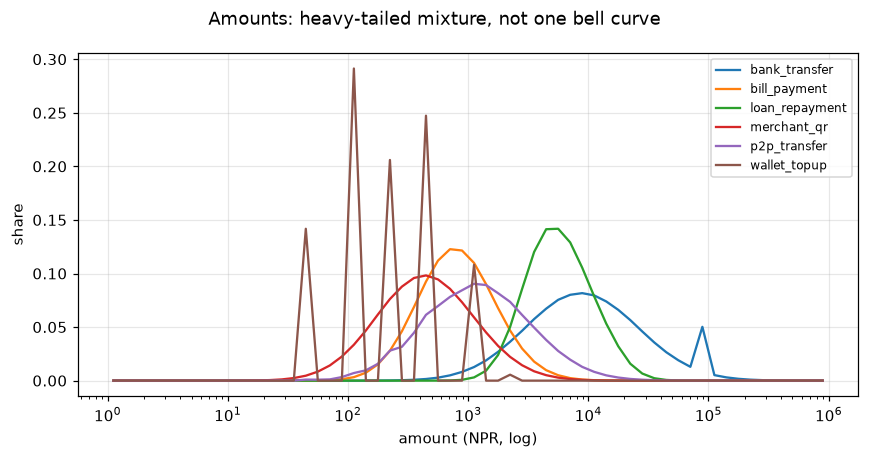

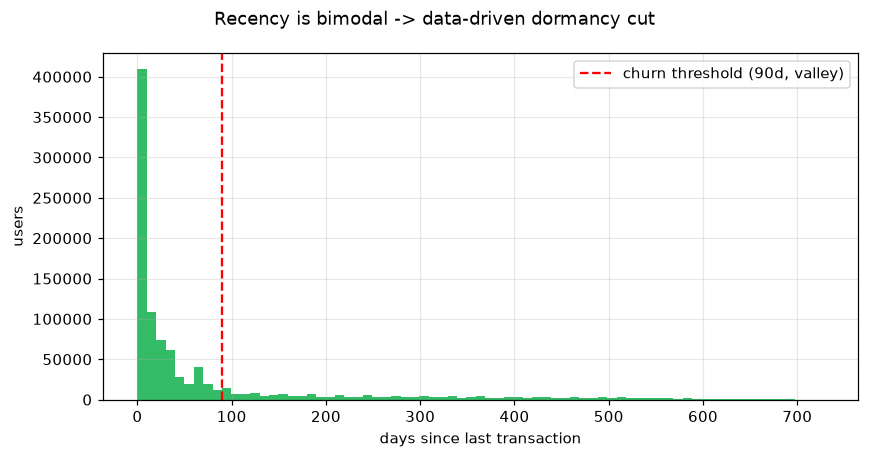

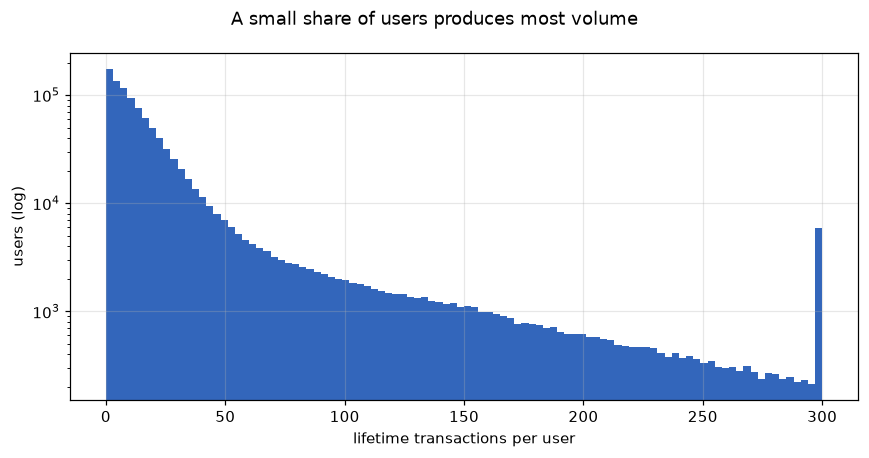

In [5]:
F = pd.read_parquet(AGG/"user_features.parquet")
D = pd.read_parquet(AGG/"daily_kpis.parquet")
H = np.load(AGG/"amount_hists.npz")

fig, ax = plt.subplots(figsize=(8,4.2))
ctr = 10 ** ((H["logbins"][:-1] + H["logbins"][1:]) / 2)
for k in H.files:
    if k.startswith("svc_"):
        v = H[k]; ax.plot(ctr, v/v.sum(), label=k[4:])
ax.set_xscale("log"); ax.set_xlabel("amount (NPR, log)"); ax.set_ylabel("share"); ax.legend(fontsize=8)
save_show(fig, "01_amount_distributions.png", "Amounts: heavy-tailed mixture, not one bell curve")

fig, ax = plt.subplots(figsize=(8,4.2))
ax.hist(F.loc[F.n_tx>0, "recency_d"].clip(upper=729), bins=73, color="#3b6")
ax.axvline(90, color="r", ls="--", label="churn threshold (90d, valley)")
ax.set_xlabel("days since last transaction"); ax.set_ylabel("users"); ax.legend()
save_show(fig, "02_recency_distribution.png", "Recency is bimodal -> data-driven dormancy cut")

fig, ax = plt.subplots(figsize=(8,4.2))
ax.hist(F.n_tx.clip(upper=300), bins=100, color="#36b", log=True)
ax.set_xlabel("lifetime transactions per user"); ax.set_ylabel("users (log)")
save_show(fig, "03_user_activity_distribution.png", "A small share of users produces most volume")

## 5 · Key findings from exploring the data
Each chart below points to a specific business concern and a recommended action.
1. **New users fail payments far more often** - about 3.5x higher than experienced users - right when trust matters most.
2. **A failed first payment costs about 21 percentage points of retention**, connecting payment failures directly to poor new-user retention and wasted marketing spend. *Recommended action: fix the underlying issue and add an automatic retry / apology credit for failed first payments.*
3. The **signup journey** shows where people drop off (starting verification, completing verification, making their first transaction).
4. A **spike in failures in March 2026** was traced to two specific payment types over two weeks, with normal transaction sizes and volumes - this points to a technical outage, not fraud (I also checked for and ruled out a logging error as the cause).
5. **Some bank transfers cluster just under Rs 100,000** - a pattern often associated with people avoiding a reporting threshold - flagged for risk review.
6. A monthly transaction-volume trend, with a simple projection of where it's heading if nothing changes (a rough trendline, not a formal forecast).


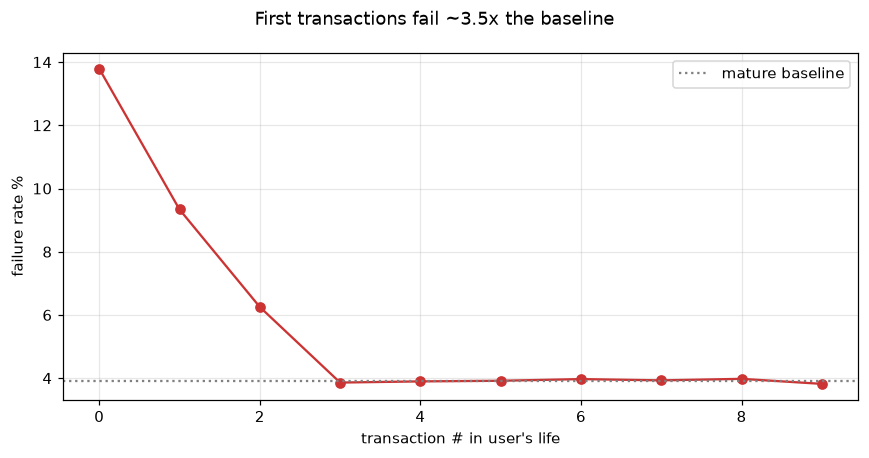

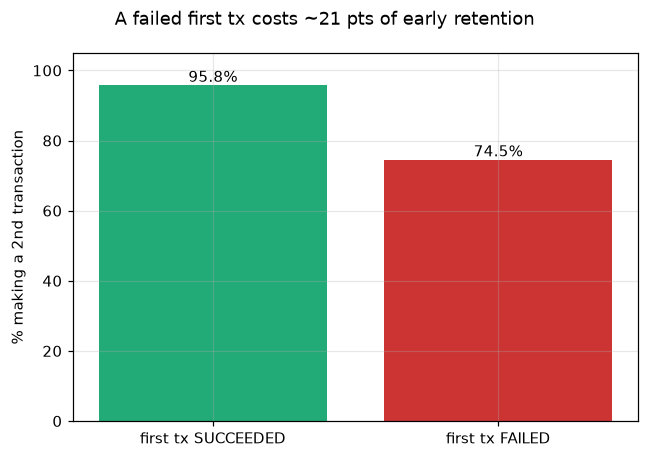

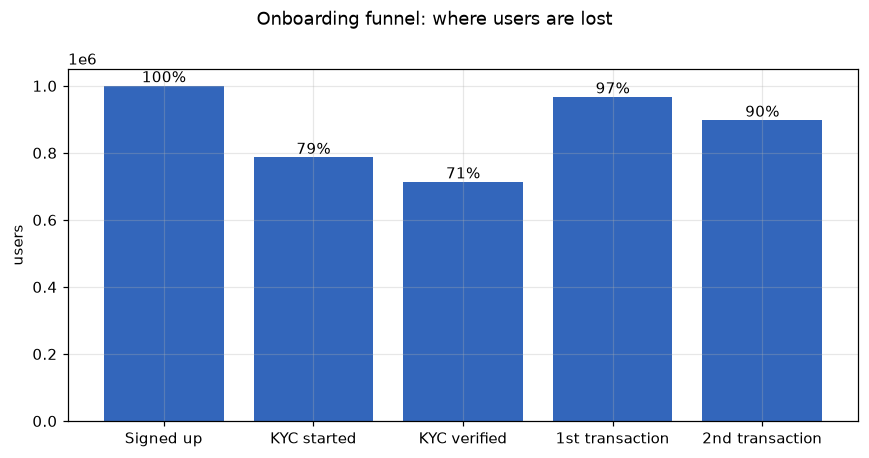

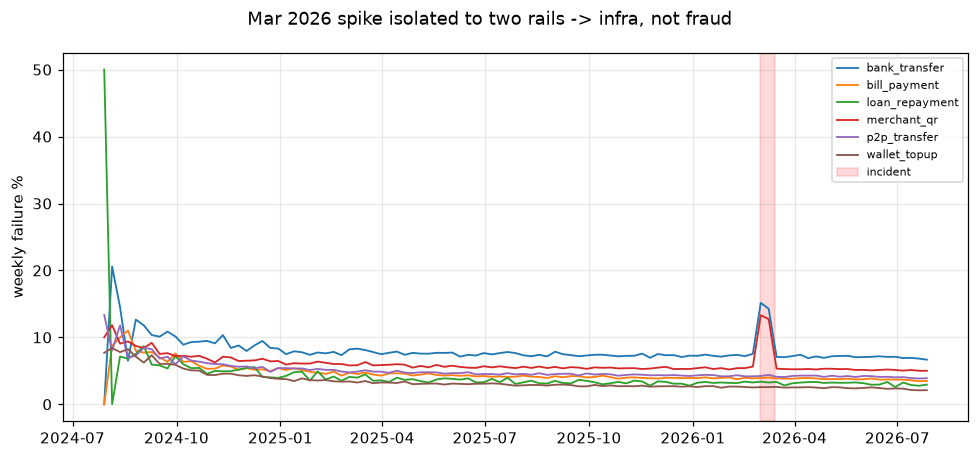

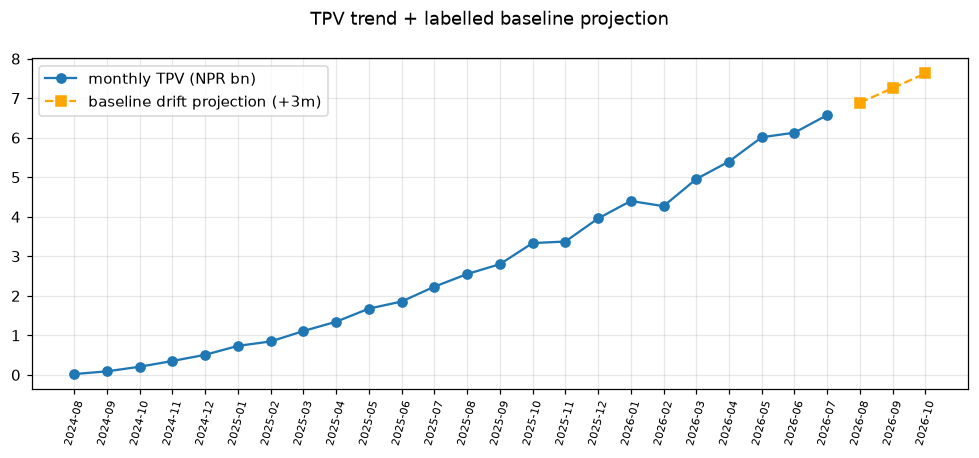

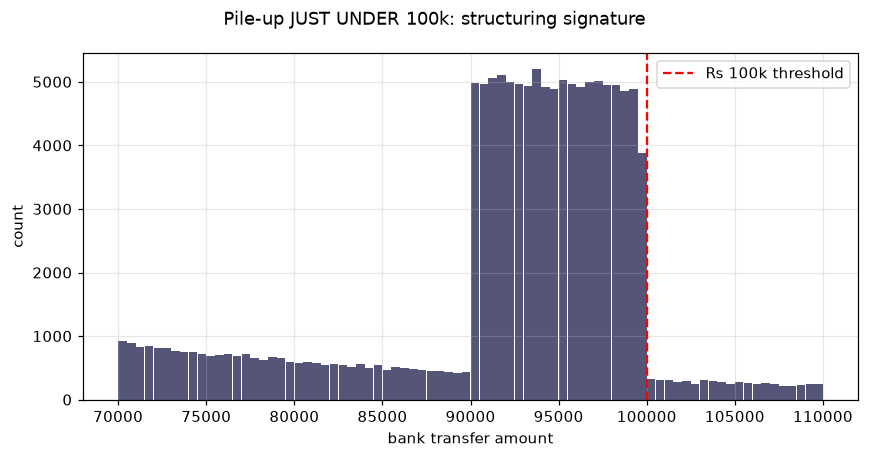

In [6]:
sq = pd.read_csv(AGG/"seq_failure_counts.csv", index_col=0)
rate = sq["True"] / sq.sum(axis=1) * 100
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(rate.index, rate.values, "o-", color="#c33")
ax.axhline(rate.values[4:].mean(), color="gray", ls=":", label="mature baseline")
ax.set_xlabel("transaction # in user's life"); ax.set_ylabel("failure rate %"); ax.legend()
save_show(fig, "04_failure_by_sequence.png", "First transactions fail ~3.5x the baseline")

act = F[F.n_tx > 0]
ret = (act.assign(second=act.n_tx>=2).groupby("first_failed", observed=True).second.mean()*100)
fig, ax = plt.subplots(figsize=(6,4.2))
ax.bar(["first tx SUCCEEDED","first tx FAILED"], [ret[False], ret[True]], color=["#2a7","#c33"])
for i, v in enumerate([ret[False], ret[True]]): ax.text(i, v+1, f"{v:.1f}%", ha="center")
ax.set_ylabel("% making a 2nd transaction"); ax.set_ylim(0,105)
save_show(fig, "05_retention_first_outcome.png", "A failed first tx costs ~21 pts of early retention")

stages = ["Signed up","KYC started","KYC verified","1st transaction","2nd transaction"]
nvals = [len(F), F.kyc_status.isin(["pending","verified","rejected"]).sum(),
         (F.kyc_status=="verified").sum(), (F.n_tx>=1).sum(), (F.n_tx>=2).sum()]
fig, ax = plt.subplots(figsize=(8,4.2))
ax.bar(stages, nvals, color="#36b")
for i, v in enumerate(nvals): ax.text(i, v, f"{v/nvals[0]:.0%}", ha="center", va="bottom")
ax.set_ylabel("users")
save_show(fig, "06_kyc_funnel.png", "Onboarding funnel: where users are lost")

W = pd.read_parquet(AGG/"weekly_fail.parquet")
fig, ax = plt.subplots(figsize=(9,4.2))
for s, sub in W.groupby("service_type", observed=True):
    sub = sub.sort_values("week"); ax.plot(sub.week, sub.n_fail/sub.n*100, label=s, lw=1.2)
ax.axvspan(pd.Timestamp("2026-03-01"), pd.Timestamp("2026-03-15"), color="red", alpha=.15, label="incident")
ax.set_ylabel("weekly failure %"); ax.legend(fontsize=7)
save_show(fig, "07_weekly_failure_incident.png", "Mar 2026 spike isolated to two rails -> infra, not fraud")

M = (D[D.status=="success"].assign(month=D.date.dt.to_period("M"))
     .groupby("month").amount.sum() / 1e9)
M = M[M.index < pd.Period("2026-08")]
x = np.arange(len(M)); sl, ic = np.polyfit(x[-12:], M.values[-12:], 1)
fx = np.arange(len(M), len(M)+3)
fig, ax = plt.subplots(figsize=(9,4.2))
ax.plot(M.index.astype(str), M.values, "o-", label="monthly TPV (NPR bn)")
ax.plot([str(M.index[-1]+i+1) for i in range(3)], ic + sl*fx, "s--", color="orange",
        label="baseline drift projection (+3m)")
ax.tick_params(axis="x", rotation=75, labelsize=7); ax.legend()
save_show(fig, "08_monthly_tpv_projection.png", "TPV trend + labelled baseline projection")

fig, ax = plt.subplots(figsize=(8,4.2))
bctr = (H["bankbins"][:-1] + H["bankbins"][1:]) / 2
ax.bar(bctr, H["bankhist"], width=480, color="#557")
ax.axvline(100_000, color="r", ls="--", label="Rs 100k threshold")
ax.set_xlabel("bank transfer amount"); ax.set_ylabel("count"); ax.legend()
save_show(fig, "09_bank_structuring.png", "Pile-up JUST UNDER 100k: structuring signature")

## 5b · Statistical checks: hypothesis test, correlations, dimensionality reduction

Three formal checks to back the findings above. First, a two-proportion z-test on the biggest claim: that a failed first payment lowers the chance of a second one. Second, Spearman rank correlations between the customer features (Spearman because the variables are heavily skewed). Third, PCA, to see how much of customer behaviour fits into a few independent dimensions - which also sanity-checks the small feature set I use for segmentation in the next section.

retention if first failed: 74.50% (n=133,310) | if first succeeded: 95.75% (n=833,248)
difference 21.25%, 95% CI [21.02%, 21.49%], z=279, p=<1e-300
=> reject H0: the gap is real, not sampling noise



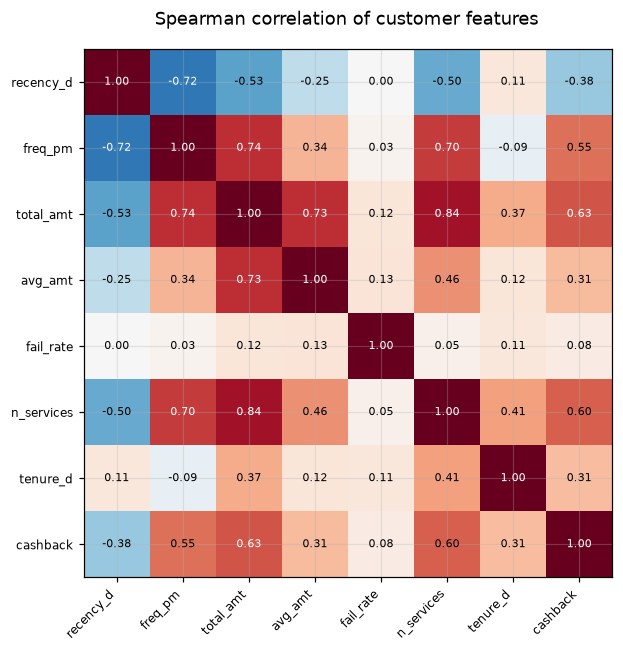

Engagement features move together (freq~spend 0.74, services~spend 0.84, recency~freq -0.72)
while fail_rate is independent of all of them: risk is not just low engagement,
which is why the Risky group is detected by rule rather than by clustering.


In [7]:
from scipy import stats

F = pd.read_parquet(AGG/"user_features.parquet")
A = F[F.n_tx > 0].copy()

# Hypothesis test. H0: retention is the same whether the first payment failed or not.
g = A.assign(second=A.n_tx >= 2).groupby("first_failed", observed=True).second.agg(["sum","count"])
x1, n1 = g.loc[True, "sum"], g.loc[True, "count"]      # first payment failed
x2, n2 = g.loc[False, "sum"], g.loc[False, "count"]    # first payment succeeded
p1, p2 = x1/n1, x2/n2
pp = (x1 + x2) / (n1 + n2)
z = (p2 - p1) / np.sqrt(pp*(1-pp)*(1/n1 + 1/n2))
se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
pval = 2 * stats.norm.sf(abs(z))
print(f"retention if first failed: {p1:.2%} (n={n1:,}) | if first succeeded: {p2:.2%} (n={n2:,})")
print(f"difference {p2-p1:.2%}, 95% CI [{p2-p1-1.96*se:.2%}, {p2-p1+1.96*se:.2%}], "
      f"z={z:.0f}, p={'<1e-300' if pval == 0 else f'{pval:.1e}'}")
print("=> reject H0: the gap is real, not sampling noise\n")

# Spearman correlations (rank-based, robust to heavy skew)
cols = ["recency_d","freq_pm","total_amt","avg_amt","fail_rate","n_services","tenure_d","cashback"]
C = A[cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.6, 6))
ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(cols)), cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{C.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(C.iloc[i,j]) > .6 else "black")
save_show(fig, "14_correlation_heatmap.png", "Spearman correlation of customer features")
print("Engagement features move together (freq~spend 0.74, services~spend 0.84, recency~freq -0.72)")
print("while fail_rate is independent of all of them: risk is not just low engagement,")
print("which is why the Risky group is detected by rule rather than by clustering.")

explained variance by component: [0.55  0.179 0.117 0.097 0.05  0.006] | first two: 0.729
PC1 loadings: {'recency_d': np.float32(-0.33), 'log_freq': np.float32(0.44), 'log_monetary': np.float32(0.52), 'log_avg_amt': np.float32(0.35), 'fail_rate': np.float32(-0.28), 'n_services': np.float32(0.48)}


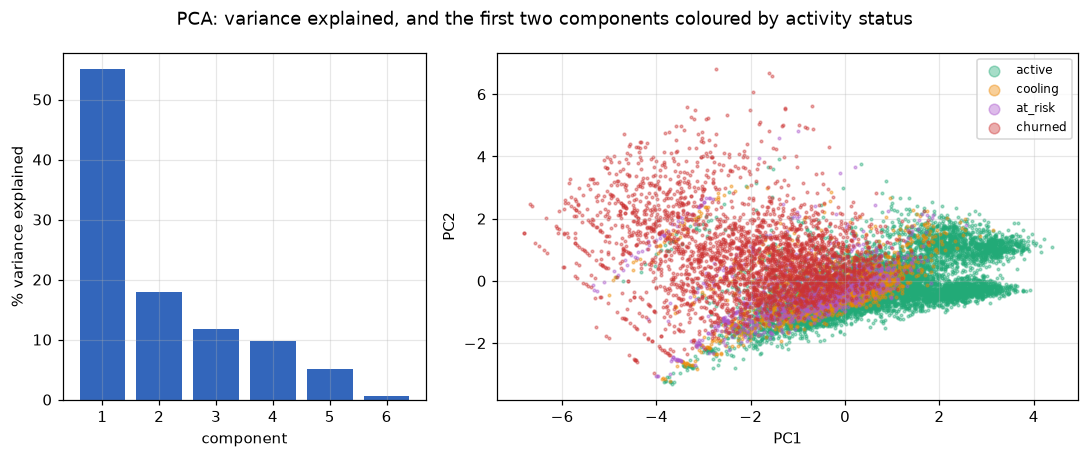

PC1 is an engagement-and-value axis (positive freq/spend/diversity, negative recency);
churned customers separate along it without churn ever being an input to the PCA.


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feats = pd.DataFrame({
    "recency_d": A.recency_d, "log_freq": np.log1p(A.freq_pm),
    "log_monetary": np.log10(A.total_amt + 1), "log_avg_amt": np.log1p(A.avg_amt),
    "fail_rate": A.fail_rate, "n_services": A.n_services})
X = StandardScaler().fit_transform(feats).astype(np.float32)
pca = PCA().fit(X)
ev = pca.explained_variance_ratio_
print("explained variance by component:", np.round(ev, 3), "| first two:", round(ev[:2].sum(), 3))
print("PC1 loadings:", dict(zip(feats.columns, np.round(pca.components_[0], 2))))

Z = pca.transform(X)[:, :2]
rng2 = np.random.default_rng(1)
idx = rng2.choice(len(Z), 15_000, replace=False)
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), width_ratios=[1, 1.6])
axs[0].bar(range(1, len(ev)+1), ev*100, color="#36b")
axs[0].set_xlabel("component"); axs[0].set_ylabel("% variance explained")
for flag, col in [("active","#2a7"), ("cooling","#e80"), ("at_risk","#a5c"), ("churned","#c33")]:
    m = (A.status_flag.values[idx] == flag)
    axs[1].scatter(Z[idx][m, 0], Z[idx][m, 1], s=3, alpha=.4, label=flag, color=col)
axs[1].set_xlabel("PC1"); axs[1].set_ylabel("PC2"); axs[1].legend(markerscale=4, fontsize=8)
save_show(fig, "15_pca.png", "PCA: variance explained, and the first two components coloured by activity status")
print("PC1 is an engagement-and-value axis (positive freq/spend/diversity, negative recency);")
print("churned customers separate along it without churn ever being an input to the PCA.")

## 6 · Grouping customers into segments
**How I grouped them.** I used a clustering method (KMeans) that's fast enough to handle 1 million users and produces clear, easy-to-interpret groups - a good fit since the brief asked for a fixed set of customer personas. I considered other clustering methods but ruled them out: one doesn't work well with a fixed number of groups and would leave many users unclassified; another doesn't scale to a dataset this large. I also rescaled the skewed measures (like spending, where a few very large values exist) onto a more even scale first, so those extreme values wouldn't unfairly dominate the grouping.

**First pass.** I grouped users by recency, frequency, spending, failure rate, and verification status together. Checking it against the hidden answer key turned up two problems: verification status was overpowering the other factors, and users with very little history looked artificially "risky" (e.g. 1 failure out of 2 transactions looks like a 50% failure rate, even though it's really just bad luck with a small sample).


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

F = pd.read_parquet(AGG/"user_features.parquet")
A = F[F.n_tx > 0].copy()
A["log_monetary"]   = np.log10(A.total_amt + 1)
A["kyc_incomplete"] = (~A.kyc_status.eq("verified")).astype(float)
X1 = StandardScaler().fit_transform(
    A[["recency_d","freq_pm","log_monetary","fail_rate","kyc_incomplete"]]).astype(np.float32)
km1 = MiniBatchKMeans(5, random_state=0, n_init=10, batch_size=8192).fit(X1)
Tr = pd.read_parquet(RAW/"ground_truth.parquet")
v1 = A.assign(c=km1.labels_)
print("v1 cluster means:")
print(v1.groupby("c")[["recency_d","freq_pm","total_amt","fail_rate","kyc_incomplete"]]
      .mean().round(2).to_string())
print("\nv1 recovery vs held-out ground truth (row %):")
print((pd.crosstab(v1.merge(Tr, on="user_id").true_segment,
                   v1.merge(Tr, on="user_id").c, normalize="index")*100).round(1).to_string())

v1 cluster means:
   recency_d  freq_pm  total_amt  fail_rate  kyc_incomplete
c                                                          
0      31.24     1.61   33044.08       0.05            0.00
1      37.07     1.89   72506.77       0.06            1.00
2       2.07    12.10  337973.93       0.04            0.15
3     240.11     0.27    2807.08       0.83            0.29
4     407.81     0.43   10008.64       0.08            0.33

v1 recovery vs held-out ground truth (row %):
c                0     1     2    3     4
true_segment                             
dormant       31.4  20.2   0.0  6.9  41.5
high_value    24.7  13.9  55.9  4.4   1.1
power         11.0   6.9  76.5  4.9   0.8
risky         28.7  61.3   1.3  7.5   1.3
standard      73.9  19.8   0.0  5.6   0.7


**Second pass.** I made three changes: (a) I grouped customers using only recency, frequency, and spending - the classic combination this method handles best. (b) I identified "Risky" customers with a separate, explicit rule instead of folding it into the clustering - matching the brief's own definition (flagged/failed transactions, incomplete verification) - and adjusted the failure rate so customers with very few transactions aren't unfairly labeled risky just from small numbers. (c) I tested a few different numbers of groups and settled on four, balancing statistical fit against what's actually useful for the business (a purely statistical approach would have suggested three, but four maps better to real personas). Users who signed up but never made a transaction are kept in their own separate group rather than forced into a behavioral bucket.


k=3  silhouette=0.471
k=4  silhouette=0.406
k=5  silhouette=0.349
k=6  silhouette=0.391

segment profiles:
             users  recency_d  tx_per_month  lifetime_spend  fail_rate  kyc_verified
segment                                                                             
Dormant      97835     392.23          0.39         8870.81       0.21          0.74
High-Value  141821       2.74         10.37       314589.46       0.04          0.76
Power       397752      22.29          1.85        50108.89       0.05          0.73
Risky        55399     148.33          1.05        45850.65       0.48          0.07
Standard    273751      53.45          0.91         4577.45       0.09          0.78

v2 recovery vs held-out ground truth (row %):
segment       Dormant  High-Value  Power  Risky  Standard
true_segment                                             
dormant          44.2         0.1   14.1    6.8      34.8
high_value        2.8        79.7   13.7    1.8       1.9
power             2

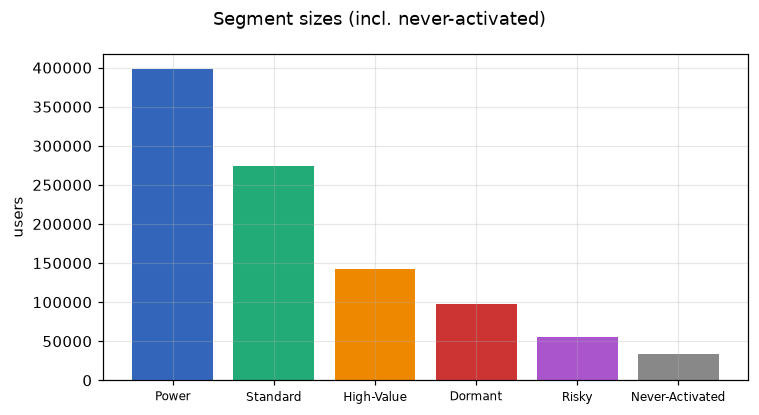

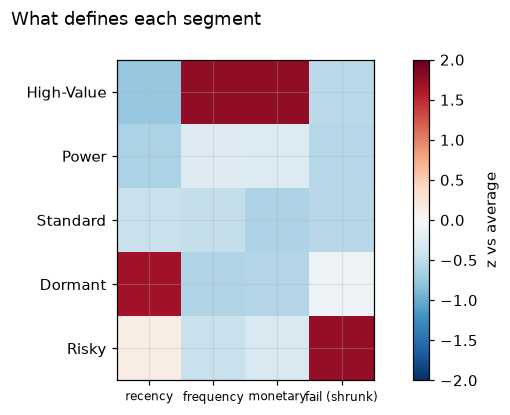

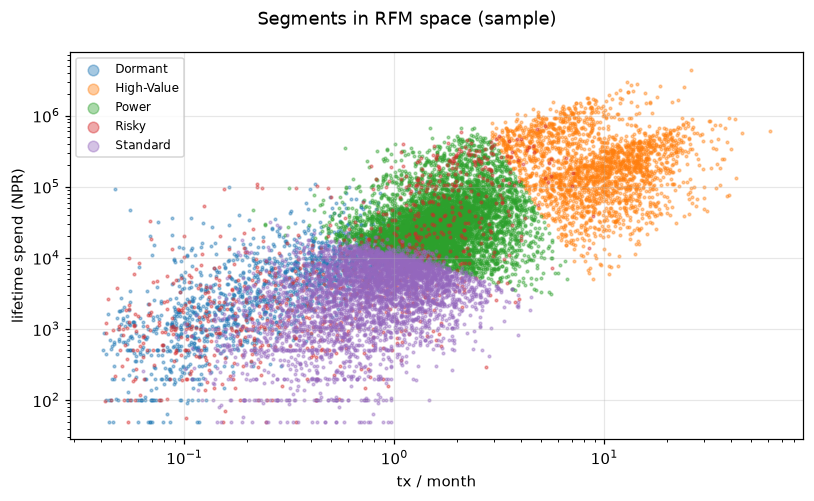

In [10]:
rng = np.random.default_rng(0)
A["log_freq"]    = np.log1p(A.freq_pm)
A["shrunk_fail"] = A.n_fail / (A.n_tx + 3)
feats = ["recency_d","log_freq","log_monetary"]
X = StandardScaler().fit_transform(A[feats]).astype(np.float32)

samp = rng.choice(len(X), min(100_000, len(X)), replace=False)
for k in (3,4,5,6):
    kmk = MiniBatchKMeans(k, random_state=0, n_init=10, batch_size=4096).fit(X[samp])
    s2 = rng.choice(samp, min(20_000, len(samp)), replace=False)
    print(f"k={k}  silhouette={silhouette_score(X[s2], kmk.predict(X[s2])):.3f}")

km = MiniBatchKMeans(4, random_state=0, n_init=20, batch_size=8192).fit(X)
A["cluster"] = km.predict(X)
C = A.groupby("cluster")[feats].mean()
names, taken = {}, set()
for metric, label in [("recency_d","Dormant"), ("log_monetary","High-Value"), ("log_freq","Power")]:
    for c in C[metric].sort_values(ascending=False).index:
        if c not in taken: names[c] = label; taken.add(c); break
names.update({c: "Standard" for c in C.index if c not in taken})
A["segment"] = A.cluster.map(names)
risk_rule = (A.shrunk_fail > 0.25) | ((~A.kyc_status.eq("verified")) & (A.fail_rate > 0.15))
A.loc[risk_rule, "segment"] = "Risky"

prof = A.groupby("segment").agg(users=("user_id","size"), recency_d=("recency_d","mean"),
    tx_per_month=("freq_pm","mean"), lifetime_spend=("total_amt","mean"),
    fail_rate=("fail_rate","mean"),
    kyc_verified=("kyc_status", lambda s: s.eq("verified").mean())).round(2)
print("\nsegment profiles:"); print(prof.to_string())
cmp = A.merge(Tr, on="user_id")
print("\nv2 recovery vs held-out ground truth (row %):")
print((pd.crosstab(cmp.true_segment, cmp.segment, normalize="index")*100).round(1).to_string())
idx = rng.choice(len(X), min(20_000, len(X)), replace=False)
print(f"silhouette (k=4 RFM): {silhouette_score(X[idx], A.cluster.values[idx]):.3f}")

seg_all = F.merge(A[["user_id","segment"]], on="user_id", how="left")
seg_all["segment"] = seg_all.segment.fillna("Never-Activated")
seg_all.to_parquet(AGG/"user_features_seg.parquet", index=False)
prof.to_csv(AGG/"segment_profiles.csv")

vc = seg_all.segment.value_counts()
fig, ax = plt.subplots(figsize=(7,3.8))
ax.bar(vc.index, vc.values, color=["#36b","#2a7","#e80","#c33","#a5c","#888"][:len(vc)])
ax.set_ylabel("users"); plt.xticks(fontsize=8)
save_show(fig, "11_segment_sizes.png", "Segment sizes (incl. never-activated)")

Pm = A.groupby("segment")[["recency_d","freq_pm","total_amt","shrunk_fail"]].mean()
Z = (Pm - Pm.mean()) / Pm.std()
order = [s for s in ["High-Value","Power","Standard","Dormant","Risky"] if s in Z.index]
fig, ax = plt.subplots(figsize=(7.5,3.8))
im = ax.imshow(Z.loc[order], cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_xticks(range(4), ["recency","frequency","monetary","fail (shrunk)"], fontsize=8)
ax.set_yticks(range(len(order)), order)
fig.colorbar(im, label="z vs average")
save_show(fig, "12_segment_profiles.png", "What defines each segment")

s = A.sample(min(15_000, len(A)), random_state=1)
fig, ax = plt.subplots(figsize=(7.5,4.6))
for name, sub in s.groupby("segment"):
    ax.scatter(sub.freq_pm.clip(lower=.01), sub.total_amt.clip(lower=1), s=3, alpha=.4, label=name)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("tx / month"); ax.set_ylabel("lifetime spend (NPR)")
ax.legend(markerscale=4, fontsize=8)
save_show(fig, "13_cluster_scatter.png", "Segments in RFM space (sample)")

**How well the grouping worked.** I ran the segmentation without looking at the hidden answer key, then checked it afterward. The resulting groups are clearly distinct from each other, which is what makes them useful for the business. Comparing against the answer key showed some overlap in a few cases - for example, a customer originally labeled "standard" who actually *behaves* like a power user ends up correctly grouped with the power users, since actual behavior matters more than the hidden label. To be upfront about limitations: the High-Value and Power-user groups overlap somewhat, since their spending and activity patterns are similar, and the rule-based "Risky" detection catches the clearest cases but not every unusual pattern. A production version of this would add more detailed behavioral signals and feedback from manual reviews.


## 7 · Dashboard data (Power BI)
All the heavy data processing happens in Python; Power BI is just used to display the results. I exported the 10 summary tables (daily/monthly KPIs, per-segment monthly TPV, the funnel, failure and retention tables, failure reasons, the bank-amount histogram, segment profiles) as sheets in a single Excel workbook, `dashboard_data.xlsx`, so Power BI only needs one import step instead of several. The 1-million-row user list is kept as its own CSV (`user_segments.csv`) since a table that size is better handled as a plain CSV than as a workbook sheet.


In [11]:
S = pd.read_parquet(AGG/"user_features_seg.parquet")
S[["user_id","segment","status_flag","kyc_status","province","referral_source","age_group",
   "gender","signup_date","n_tx","total_amt","recency_d","freq_pm","fail_rate","cashback",
   "first_failed"]].to_csv(PBI/"user_segments.csv", index=False)

D = pd.read_parquet(AGG/"daily_kpis.parquet")
Mo = (D.assign(month=D.date.dt.to_period("M").astype(str))
        .groupby(["month","service_type","status"], observed=True)
        .agg(n=("n","sum"), amount=("amount","sum"), cashback=("cashback","sum")).reset_index())
tot = (Mo[(Mo.status=="success") & (Mo.month < "2026-08")].groupby("month").amount.sum().reset_index())
x = np.arange(len(tot)); sl, ic = np.polyfit(x[-12:], tot.amount.values[-12:], 1)
proj = pd.DataFrame({"month": [str(pd.Period(tot.month.iloc[-1])+i) for i in (1,2,3)],
                     "amount": ic + sl*np.arange(len(tot), len(tot)+3), "is_projection": True})
monthly_tpv_projection = pd.concat([tot.assign(is_projection=False), proj])

seg_map = S.set_index("user_id").segment
sm = []
for p in sorted(CLEAN.glob("tx_*.parquet")):
    d = pd.read_parquet(p, columns=["user_id","timestamp","amount","status"])
    d["month"] = d.timestamp.dt.to_period("M").astype(str)
    d["segment"] = d.user_id.map(seg_map); d["failed"] = d.status.eq("failed")
    sm.append(d.groupby(["month","segment"], observed=True)
               .agg(n=("amount","size"), tpv=("amount","sum"), n_fail=("failed","sum")).reset_index())
segment_monthly = pd.concat(sm).groupby(["month","segment"], observed=True).sum().reset_index()

kyc_funnel = pd.DataFrame({"stage": ["Signed up","KYC started","KYC verified","1st transaction","2nd transaction"],
    "users": [len(S), S.kyc_status.isin(["pending","verified","rejected"]).sum(),
              (S.kyc_status=="verified").sum(), (S.n_tx>=1).sum(), (S.n_tx>=2).sum()]})

sq = pd.read_csv(AGG/"seq_failure_counts.csv", index_col=0)
failure_by_sequence = pd.DataFrame({"tx_number_in_life": sq.index,
              "failure_rate_pct": (sq["True"]/sq.sum(axis=1)*100).round(2)})

act = S[S.n_tx>0]
retention_first_outcome = (act.assign(second=act.n_tx>=2).groupby("first_failed", observed=True)
       .agg(users=("user_id","size"), pct_make_2nd=("second","mean")).reset_index())
retention_first_outcome["pct_make_2nd"] = (retention_first_outcome.pct_make_2nd*100).round(2)

failure_reasons_monthly = pd.read_parquet(AGG/"failure_reasons.parquet")

H = np.load(AGG/"amount_hists.npz")
bank_amount_hist = pd.DataFrame({"amount_bin_low": H["bankbins"][:-1], "count": H["bankhist"].astype(int)})

segment_profiles = pd.read_csv(AGG/"segment_profiles.csv")

# user_segments stays a separate CSV; too big for a workbook sheet
with pd.ExcelWriter(PBI/"dashboard_data.xlsx", engine="openpyxl") as xl:
    D.to_excel(xl, sheet_name="daily_kpis", index=False)
    Mo.to_excel(xl, sheet_name="monthly_kpis", index=False)
    monthly_tpv_projection.to_excel(xl, sheet_name="monthly_tpv_projection", index=False)
    segment_monthly.to_excel(xl, sheet_name="segment_monthly", index=False)
    kyc_funnel.to_excel(xl, sheet_name="kyc_funnel", index=False)
    failure_by_sequence.to_excel(xl, sheet_name="failure_by_sequence", index=False)
    retention_first_outcome.to_excel(xl, sheet_name="retention_first_outcome", index=False)
    failure_reasons_monthly.to_excel(xl, sheet_name="failure_reasons_monthly", index=False)
    bank_amount_hist.to_excel(xl, sheet_name="bank_amount_hist", index=False)
    segment_profiles.to_excel(xl, sheet_name="segment_profiles", index=False)

print("exports:", sorted(f.name for f in PBI.iterdir()))

exports: ['dashboard_data.xlsx', 'user_segments.csv']


## 8 · Conclusions & findings
*(The numbers below are from the full-size run: 1,000,000 users, 25,299,624 transactions. A smaller test run shows the same patterns with slightly different numbers.)*

**Data quality.** I found and removed 25,274 duplicate transactions (0.1% of the data). Every other check passed - no transactions linked to missing users, no transactions dated before signup or in the future, no negative amounts. Most "missing" data turned out to make sense (e.g. no merchant field on a top-up); income was the one field genuinely unknown for most users (72% missing), so I excluded it from the analysis.

**Finding 1 - new users who hit payment failures are much more likely to leave.** A user's very first payment fails 13.8% of the time, compared to just 3.9% for experienced users (about 3.5x higher) - and a failed first payment cuts the odds of that user ever making a second payment from 95.8% down to 74.5% (a 21-point drop). In short: payment failures → poor new-user retention → wasted marketing spend. *Recommended action: prioritize fixing first-payment reliability, and add an automatic retry or apology credit for failed first payments.*

**Finding 2 - people are dropping off before they even become active users.** About 29% of signups never finish identity verification, and 3.3% never make a single transaction. This suggests rising customer-acquisition costs are as much an onboarding problem as a marketing problem. *Recommended action: simplify the verification process and track "time to verified" as a KPI.*

**Finding 3 - the March 2026 failure spike was a technical outage, not fraud.** It was limited to two specific payment types over two weeks, with normal transaction sizes and volumes (I checked for and ruled out fraud and logging errors as explanations). *Recommended action: review the incident and revisit the payment vendor's service-level agreement.*

**Finding 4 - there are signs of suspicious activity, and they're traceable.** Some bank transfers cluster just under the Rs 100,000 reporting threshold. The "Risky" customer segment (about 5% of users) has a 48% payment failure rate and only 7% have completed verification. *Recommended action: send the under-threshold transfers and the Risky segment to the compliance/AML team for review, and tighten limits for unverified accounts.*

**Finding 5 - a small group of customers drives most of the value.** High-Value customers (about 14% of users) spend an average of NPR 315,000 over their lifetime and were active as recently as 2.7 days ago on average - retention efforts aimed at this group likely pay off better than broad new-customer marketing. Inactive ("dormant") users skew toward having originally signed up for a cashback promotion, so any win-back campaign should account for the possibility that many of them were just promo-seekers, not lost loyal customers.

**Limitations.** This dataset is synthetic - made up for this assessment and only loosely inspired by a real business - so these findings demonstrate my *method*, not real company facts. I measured transaction volume, not revenue, since there's no fee data available. The link between a failed first payment and losing that customer is deliberately built into this synthetic dataset; on real data, I'd confirm it with a proper before/after comparison or a controlled test before recommending a big investment. The hidden answer key for customer segments was only used to double-check my results at the end, not during the analysis itself - the match is good but not perfect, as explained in section 6.
